# Q9.
```{admonition}
:class: note
This problem involves the `OJ` data set.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split, KFold, GridSearchCV, cross_val_score

In [4]:
import seaborn as sns

In [ ]:
oj = pd.read_csv('../../../ALL CSV FILES - 2nd Edition/OJ.csv')

In [6]:
oj.describe()

,WeekofPurchase,StoreID,PriceCH,PriceMM,DiscCH,DiscMM,SpecialCH,SpecialMM,LoyalCH,SalePriceMM,SalePriceCH,PriceDiff,PctDiscMM,PctDiscCH,ListPriceDiff,STORE
count,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000
mean,254.381308,3.959813,1.867421,2.085411,0.051860,0.123364,0.147664,0.161682,0.565782,1.962047,1.815561,0.146486,0.059298,0.027314,0.217991,1.630841
std,15.558286,2.308984,0.101970,0.134386,0.117474,0.213834,0.354932,0.368331,0.307843,0.252697,0.143384,0.271563,0.101760,0.062232,0.107535,1.430387
min,227.000000,1.000000,1.690000,1.690000,0.000000,0.000000,0.000000,0.000000,0.000011,1.190000,1.390000,-0.670000,0.000000,0.000000,0.000000,0.000000
25%,240.000000,2.000000,1.790000,1.990000,0.000000,0.000000,0.000000,0.000000,0.325257,1.690000,1.750000,0.000000,0.000000,0.000000,0.140000,0.000000
50%,257.000000,3.000000,1.860000,2.090000,0.000000,0.000000,0.000000,0.000000,0.600000,2.090000,1.860000,0.230000,0.000000,0.000000,0.240000,2.000000
75%,268.000000,7.000000,1.990000,2.180000,0.000000,0.230000,0.000000,0.000000,0.850873,2.130000,1.890000,0.320000,0.112676,0.000000,0.300000,3.000000
max,278.000000,7.000000,2.090000,2.290000,0.500000,0.800000,1.000000,1.000000,0.999947,2.290000,2.090000,0.640000,0.402010,0.252688,0.440000,4.000000


In [7]:
oj.sample(3)

,Purchase,WeekofPurchase,StoreID,PriceCH,PriceMM,DiscCH,DiscMM,SpecialCH,SpecialMM,LoyalCH,SalePriceMM,SalePriceCH,PriceDiff,Store7,PctDiscMM,PctDiscCH,ListPriceDiff,STORE
858,CH,253,7,1.86,2.09,0.1,0.0,0,0,0.965640,2.09,1.76,0.33,Yes,0.000000,0.053763,0.23,0
144,CH,277,4,2.09,2.09,0.2,0.4,0,0,0.384000,1.69,1.89,-0.20,No,0.191388,0.095694,0.00,4
58,CH,258,7,1.86,2.18,0.0,0.0,0,0,0.864003,2.18,1.86,0.32,Yes,0.000000,0.000000,0.32,0


In [8]:
oj['Store7'] = oj['Store7'] == 'Yes'
oj['Purchase'] = oj['Purchase'].astype('category')

## (a)
```{admonition}
:class: note
Create a training set containing a random sample of 800 observations, and a test set containing the remaining observations.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(oj.iloc[:,1:],oj.iloc[:,0],random_state=1728,train_size=800,shuffle=True)
feature_count = X_train.shape[1]
features = X_train.columns

## (b)
```{admonition}
:class: note
Fit a tree to the training data, with `Purchase` as the response and the other variables as predictors. What is the training error rate?

In [10]:
rt = DecisionTreeClassifier(criterion='entropy')
rt.fit(X_train,y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [11]:
train_error = 1-accuracy_score(rt.predict(X_train),y_train)
print(f'Train error is {train_error:.4f}')

Train error is 0.0075


## (c)
```{admonition}
:class: note
Create a plot of the tree, and interpret the results. How many terminal nodes does the tree have?

Total terminal nodes: 165


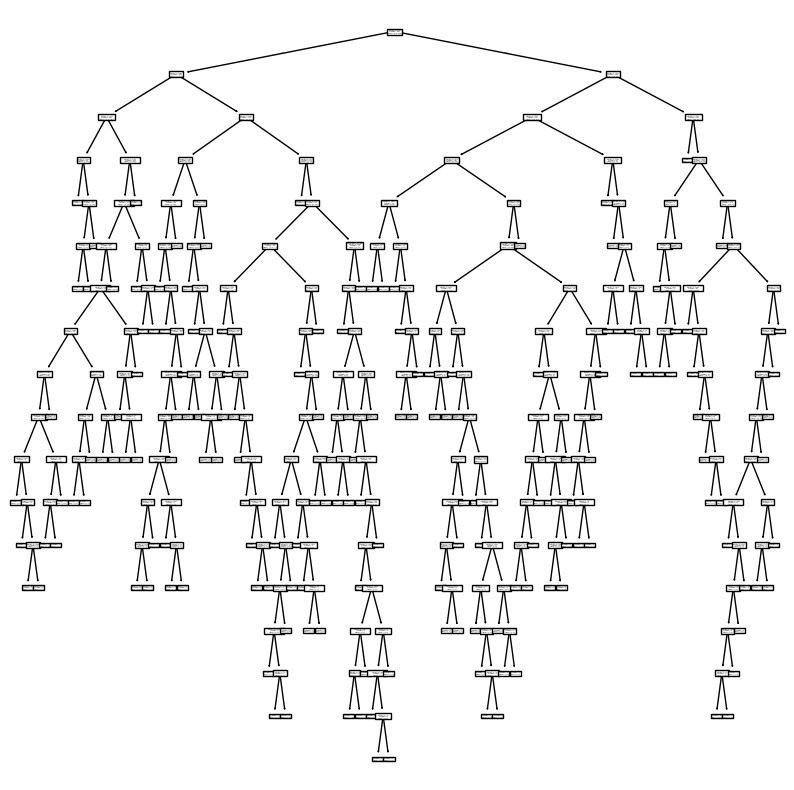

In [12]:
ax = plt.subplots(figsize=(10,10))[1]
plot_tree(rt,ax=ax,feature_names=features)
num_leaves = rt.get_n_leaves()
print(f'Total terminal nodes: {num_leaves}')
plt.show()

## (d)
```{admonition}
:class: note
Use the `export_tree()` function to produce a text summary of the fitted tree. Pick one of the terminal nodes, and interpret the information displayed.

In [13]:
print(export_text(rt,feature_names=features,max_depth=16))

|--- LoyalCH <= 0.50
|   |--- LoyalCH <= 0.28
|   |   |--- LoyalCH <= 0.04
|   |   |   |--- PriceDiff <= 0.31
|   |   |   |   |--- class: MM
|   |   |   |--- PriceDiff >  0.31
|   |   |   |   |--- LoyalCH <= 0.00
|   |   |   |   |   |--- LoyalCH <= 0.00
|   |   |   |   |   |   |--- class: MM
|   |   |   |   |   |--- LoyalCH >  0.00
|   |   |   |   |   |   |--- class: CH
|   |   |   |   |--- LoyalCH >  0.00
|   |   |   |   |   |--- class: MM
|   |   |--- LoyalCH >  0.04
|   |   |   |--- WeekofPurchase <= 273.50
|   |   |   |   |--- WeekofPurchase <= 263.50
|   |   |   |   |   |--- WeekofPurchase <= 257.50
|   |   |   |   |   |   |--- WeekofPurchase <= 249.50
|   |   |   |   |   |   |   |--- STORE <= 1.50
|   |   |   |   |   |   |   |   |--- PriceDiff <= 0.23
|   |   |   |   |   |   |   |   |   |--- ListPriceDiff <= 0.18
|   |   |   |   |   |   |   |   |   |   |--- LoyalCH <= 0.15
|   |   |   |   |   |   |   |   |   |   |   |--- class: CH
|   |   |   |   |   |   |   |   |   |   |--- Loya

From the first node, we go left at LoyalCH value splits 0.5, 0.28, 0.04. Then if PriceDiff is less than 0.31, we choose the class label MM.

## (e) 
```{admonition}
:class: note
Predict the response on the test data, and produce a confusion matrix comparing the test labels to the predicted test labels. What is the test error rate?

Test error is 0.2370


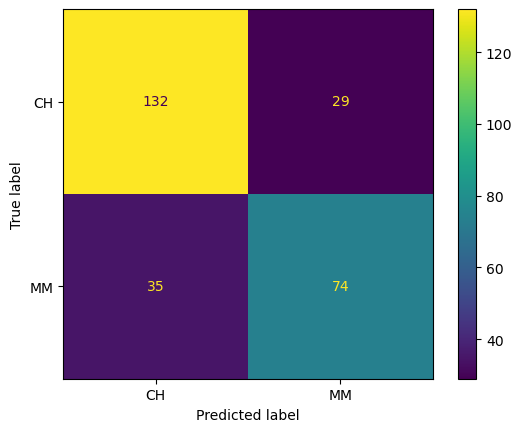

In [14]:
y_pred = rt.predict(X_test)
test_error = 1-accuracy_score(y_pred,y_test)
rt_confusion = confusion_matrix(y_test,y_pred)
print(f'Test error is {test_error:.4f}')

cm_disp = ConfusionMatrixDisplay(rt_confusion,display_labels=rt.classes_)
cm_disp.plot()
plt.show()

## (f)
```{admonition}
:class: note
Use cross-validation on the training set in order to determine the optimal tree size.

In [15]:
outer_cv = KFold(5,shuffle=True,random_state=1729)
inner_cv = KFold(5,shuffle=True,random_state=1729)

dtc = DecisionTreeClassifier(criterion='entropy')

grid = GridSearchCV(dtc,param_grid={'max_depth':np.arange(1,20)},cv=inner_cv,scoring='accuracy',n_jobs=-1)
outer_cv_score = np.mean(1-cross_val_score(grid,X_train,y_train,cv=outer_cv,scoring='accuracy'))
grid.fit(X_train,y_train)

best_tree = grid.best_estimator_
best_tree_depth = best_tree.get_depth()
test_error_best = 1-accuracy_score(best_tree.predict(X_test),y_test)

print(f'Nested CV test prediction: {outer_cv_score:.4f}')
print(f'Cross validation chose depth of {best_tree_depth} giving test error {test_error_best:.4f}')

Nested CV test prediction: 0.2113
Cross validation chose depth of 4 giving test error 0.1815


## (g)
```{admonition}
:class: note
Produce a plot with tree size on the $x$-axis and cross-validated classification error rate on the $y$-axis.

In [16]:
best_error = 1
best_model = None
depths = np.arange(1,20)
errors = np.empty(len(depths))
for j in range(len(depths)):
    dtc_j = DecisionTreeClassifier(max_depth=depths[j])
    cv_mean_error = np.mean(1-cross_val_score(dtc_j,X_train,y_train,cv=outer_cv,scoring='accuracy'))
    errors[j] = np.mean(cv_mean_error)
    if errors[j] < best_error:
        best_error = errors[j]
        best_model = dtc_j
        best_depth = depths[j]
        best_depth_idy = j

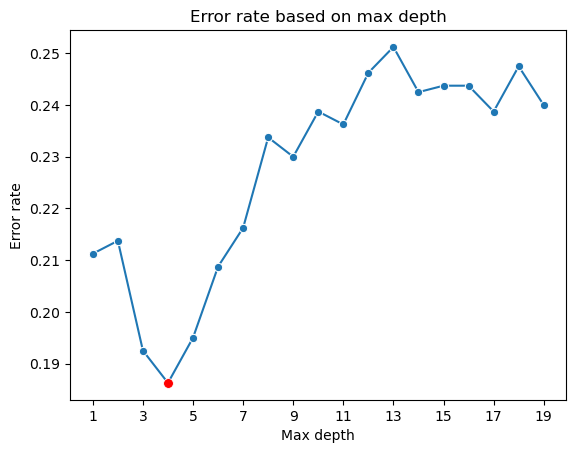

In [17]:
ax = plt.subplot()
sns.lineplot(x=depths,y=errors,marker='o')
sns.scatterplot(x=[best_depth],y=errors[best_depth_idy],color='red',s=50,zorder=2)
ax.set_xticks(depths[::2])
ax.set_ylabel('Error rate')
ax.set_xlabel('Max depth')
ax.set_title('Error rate based on max depth')
plt.show()

## (h)
```{admonition}
:class: note
Which tree size corresponds to the lowest cross-validated classification error rate.

In [18]:
best_model.fit(X_train,y_train)
best_leaves = best_model.get_n_leaves()
print(f'Best cross validation error is {best_error:.4f} with a depth of {best_depth} and {best_leaves} leaves.')

Best cross validation error is 0.1862 with a depth of 4 and 16 leaves.


## (i)
```{admonition}
:class: note
Produce a pruned tree corresponding to the optimal tree size obtained using cross-validation. If cross-validation does not lead to selection of a pruned tree, then create a pruned tree with five terminal nodes.

In [19]:
ccp_alphas = best_model.cost_complexity_pruning_path(X_train, y_train).ccp_alphas

grid_alpha = GridSearchCV(best_model,{'ccp_alpha':ccp_alphas},refit=True,cv=outer_cv,scoring='accuracy')
grid_alpha.fit(X_train,y_train)

,estimator,DecisionTreeC...h=np.int64(4))
,param_grid,{'ccp_alpha': array([0. ... 0.15782488])}
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [20]:
best_pruned = grid_alpha.best_estimator_

In [21]:
print('Leaves in original tree:', best_leaves)
print('Leaves in pruned tree:', grid_alpha.best_estimator_.get_n_leaves())

Leaves in original tree: 16
Leaves in pruned tree: 4


## (j)
```{admonition}
:class: note
Compare the training error rates between the pruned and unpruned trees.

In [22]:
unpruned_train_error = 1-accuracy_score(best_model.predict(X_train),y_train)
pruned_train_error = 1-accuracy_score(best_pruned.predict(X_train),y_train)
print(f'Pruned tree train error is {pruned_train_error:.4f}')
print(f'Unpruned tree train error is {unpruned_train_error:.4f}')

Pruned tree train error is 0.1787
Unpruned tree train error is 0.1525


## (k)
```{admonition}
:class: note
Compare the test error rates between the pruned and unpruned trees.

In [23]:
unpruned_test_error = 1-accuracy_score(best_model.predict(X_test),y_test)
pruned_test_error = 1-accuracy_score(best_pruned.predict(X_test),y_test)
print(f'Pruned tree test error is {pruned_test_error:.4f}')
print(f'Unpruned tree test error is {unpruned_test_error:.4f}')

Pruned tree test error is 0.1852
Unpruned tree test error is 0.1852
